# Exploratory Data Analysis



In [4]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sqlalchemy import text
import database as db

pd.set_option('display.max_colwidth', 100)
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Dataset Overview

In [5]:
with db.get_connection() as conn:
    df = pd.read_sql(text('''
        SELECT article_id, published_at, publication_date, publication_week,
               article_length_words, article_length_chars, duplicate_status, processing_status
        FROM processed_news
    '''), conn)

df['published_at'] = pd.to_datetime(df['published_at'])

print(f"Total articles: {len(df):,}")
print(f"Date range: {df['published_at'].min().date()} to {df['published_at'].max().date()}")
print(f"Distinct dates with coverage: {df['publication_date'].nunique()}")
print(f"Processing status breakdown:\n{df['processing_status'].value_counts()}")

Total articles: 16,794
Date range: 2023-09-28 to 2026-08-17
Distinct dates with coverage: 571
Processing status breakdown:
processing_status
COMPLETED    16792
FAILED           2
Name: count, dtype: int64


## 2. Article Volume Over Time (Weekly)

This chart makes the year-long data gap visible.

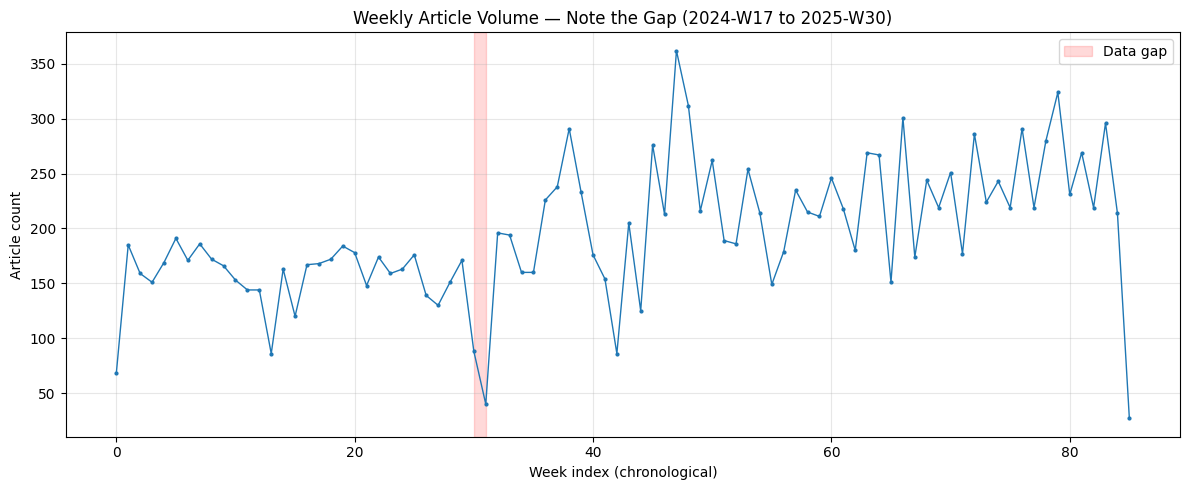

In [6]:
weekly_counts = df.groupby('publication_week').size()

fig, ax = plt.subplots()
ax.plot(range(len(weekly_counts)), weekly_counts.values, marker='o', markersize=2, linewidth=1)
ax.set_xlabel('Week index (chronological)')
ax.set_ylabel('Article count')
ax.set_title('Weekly Article Volume — Note the Gap (2024-W17 to 2025-W30)')
ax.grid(alpha=0.3)

# Annotate the known gap if present
weeks_list = list(weekly_counts.index)
if '2024-W17' in weeks_list and '2025-W30' in weeks_list:
    gap_start = weeks_list.index('2024-W17')
    gap_end = weeks_list.index('2025-W30')
    ax.axvspan(gap_start, gap_end, alpha=0.15, color='red', label='Data gap')
    ax.legend()

plt.tight_layout()
plt.show()

## 3. Duplicate Detection Results

duplicate_status
UNIQUE             16763
EXACT_DUPLICATE       25
NEAR_DUPLICATE         4
Name: count, dtype: int64


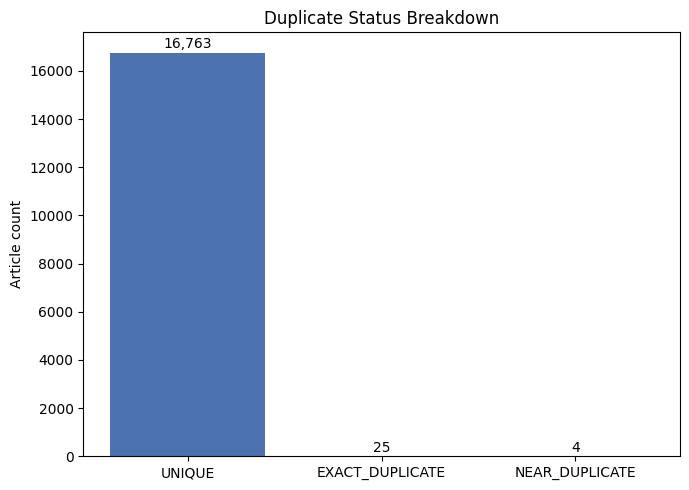

In [7]:
dup_counts = df['duplicate_status'].value_counts()
print(dup_counts)

fig, ax = plt.subplots(figsize=(7, 5))
colors = {'UNIQUE': '#4C72B0', 'EXACT_DUPLICATE': '#DD8452', 'NEAR_DUPLICATE': '#C44E52'}
bars = ax.bar(dup_counts.index, dup_counts.values, color=[colors.get(k, 'gray') for k in dup_counts.index])
ax.set_ylabel('Article count')
ax.set_title('Duplicate Status Breakdown')
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:,}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center')
plt.tight_layout()
plt.show()

## 4. Content Length Distribution

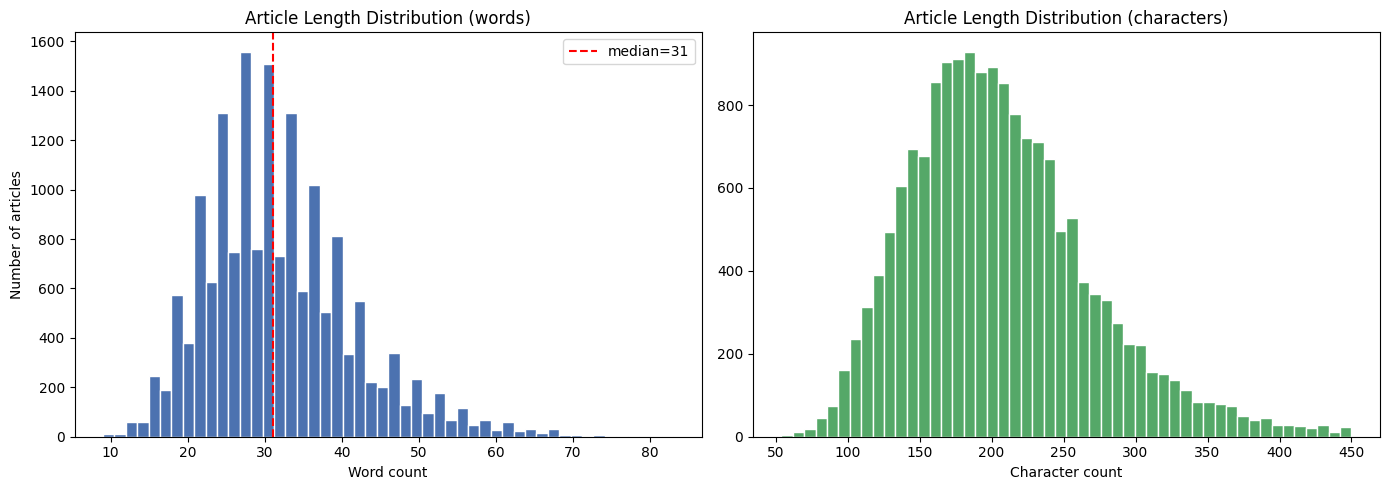

       article_length_words  article_length_chars
count          16792.000000          16792.000000
mean              31.930503            206.056336
std                9.686953             63.258821
min                9.000000             54.000000
25%               25.000000            161.000000
50%               31.000000            198.000000
75%               37.000000            242.000000
max               83.000000            450.000000


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['article_length_words'].dropna(), bins=50, color='#4C72B0', edgecolor='white')
axes[0].set_xlabel('Word count')
axes[0].set_ylabel('Number of articles')
axes[0].set_title('Article Length Distribution (words)')
axes[0].axvline(df['article_length_words'].median(), color='red', linestyle='--',
                 label=f"median={df['article_length_words'].median():.0f}")
axes[0].legend()

axes[1].hist(df['article_length_chars'].dropna(), bins=50, color='#55A868', edgecolor='white')
axes[1].set_xlabel('Character count')
axes[1].set_title('Article Length Distribution (characters)')

plt.tight_layout()
plt.show()

print(df[['article_length_words', 'article_length_chars']].describe())

## 5. Day-of-Week Publishing Pattern

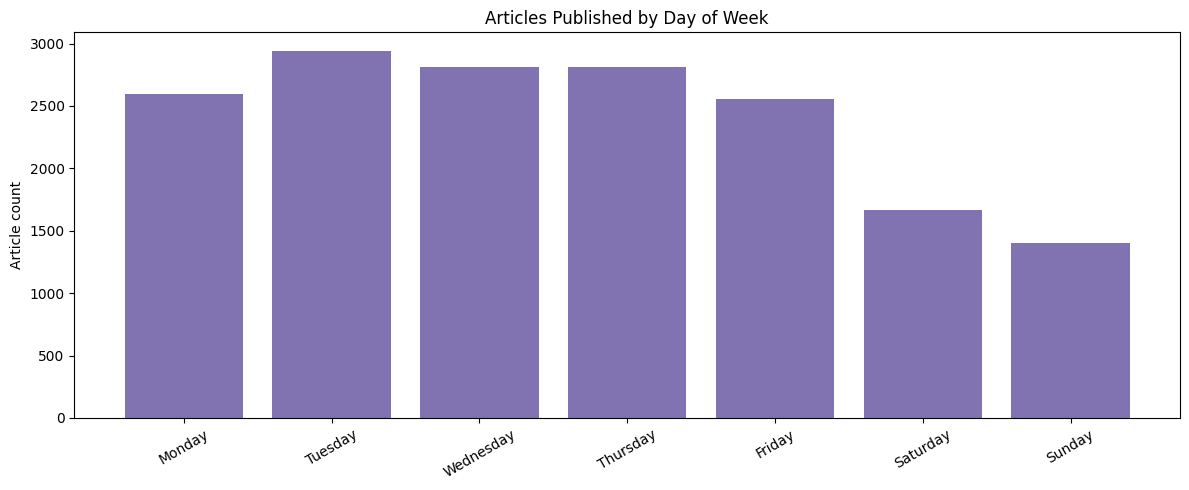

In [9]:
df['day_of_week'] = df['published_at'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['day_of_week'].value_counts().reindex(day_order)

fig, ax = plt.subplots()
ax.bar(day_counts.index, day_counts.values, color='#8172B2')
ax.set_ylabel('Article count')
ax.set_title('Articles Published by Day of Week')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()